In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
!pip install catboost
!pip install boruta

In [6]:
!pip install pandas numpy matplotlib  xgboost lightgbm catboost boruta

  Using cached pandas-2.2.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.8.4-cp312-cp312-win_amd64.whl.metadata (5.9 kB)
  Using cached catboost-1.2.3-cp312-cp312-win_amd64.whl.metadata (1.2 kB)
  Using cached contourpy-1.2.1-cp312-cp312-win_amd64.whl.metadata (5.8 kB)
Using cached pandas-2.2.2-cp312-cp312-win_amd64.whl (11.5 MB)
Using cached matplotlib-3.8.4-cp312-cp312-win_amd64.whl (7.7 MB)
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.1/99.8 MB 3.2 MB/s eta 0:00:32
   ---------------------------------------- 0.9/99.8 MB 11.5 MB/s eta 0:00:09
    --------------------------------------- 2.0/99.8 MB 16.0 MB/s eta 0:00:07
   - -------------------------------------- 2.7/99.8 MB 15.7 MB/s eta 0:00:07
   - -------------------------------------- 3.5/99.8 MB 16.1 MB/s eta 0:00:06
   - -------------------------------------- 4.4/99.8 MB 16.3 MB/s eta 0:00:06
   -- ----------------------------------

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\A\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\catboost\\_catboost.pyd'
Consider using the `--user` option or check the permissions.



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score, auc

from sklearn.model_selection import KFold, cross_val_score,cross_validate
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel

from boruta import BorutaPy

In [9]:
# load files

# merged1 = pd.read_csv('/content/drive/My Drive/Research/Data/new_merged_original_squared.csv')
# merged2 = pd.read_csv('/content/drive/My Drive/Research/Data/new_merged_original_log.csv')
# merged3 = pd.read_csv('/content/drive/My Drive/Research/Data/new_merged_original_wavelet.csv')

merged1 = pd.read_csv("C:\\Users\\A\\Desktop\\Research_Project\\Data\\new_merged_original_squared.csv")
merged2 = pd.read_csv("C:\\Users\\A\\Desktop\\Research_Project\\Data\\new_merged_original_log.csv")
merged3 = pd.read_csv("C:\\Users\\A\\Desktop\\Research_Project\\Data\\new_merged_original_wavelet.csv")
# fullmasked
# imageonly = pd.read_csv('/content/drive/My Drive/Research/Data/imagedata_complete.csv')

# 350x350 masked
# mmimg = pd.read_csv('/content/drive/My Drive/Research/Data/EXF.csv')


In [10]:
# imageonly

In [11]:
# prepare for analysis

# imageonly = imageonly.drop(columns=['US_Number'])
# imageonly = imageonly.drop_duplicates()

# mmimg = mmimg.drop(columns=['Unnamed: 0','US_Number'])
# mmimg = mmimg.drop_duplicates()

merged1 = merged1.drop(columns='US_Number')
merged1 = merged1.drop_duplicates()

merged2 = merged2.drop(columns='US_Number')
merged2 = merged2.drop_duplicates()

merged3 = merged3.drop(columns='US_Number')
merged3 = merged3.drop_duplicates()

In [12]:
# imageonly

In [13]:
# feature set division for imageonly (run after the previous column)

# original = [col for col in imageonly.columns if col.startswith('original')]
# squared = [col for col in imageonly.columns if col.startswith('square')]
# log = [col for col in imageonly.columns if col.startswith('log')]
# wavelet = [col for col in imageonly.columns if col.startswith('wavelet')]

# cut1 = imageonly.loc[:,original+squared+['Diagnosis']]
# cut2 = imageonly.loc[:,original+log+['Diagnosis']]
# cut3 = imageonly.loc[:,original+wavelet+['Diagnosis']]


**CODE ANALYSIS**

Feature Selection ⚓

Initializing Classifiers

In [14]:
# Common Ones (really, I have no idea what to call this bunch!)

# k nearest neighbors
KNN = KNeighborsClassifier(
    n_neighbors=5,      # Number of neighbors (common values: integers like 3, 5, 7)
    weights='uniform',  # Weight function used in prediction ('uniform' or 'distance')
    algorithm='auto',   # Algorithm used to compute nearest neighbors ('auto', 'ball_tree', 'kd_tree', 'brute')
    leaf_size=30,       # Leaf size passed to BallTree or KDTree (common values: integers like 10, 30, 50)
    p=2,                # Power parameter for the Minkowski metric (common values: 1 for Manhattan distance, 2 for Euclidean distance)
    metric='minkowski', # Distance metric for KNN ('euclidean', 'manhattan', 'chebyshev', 'minkowski')
    metric_params=None, # Additional keyword arguments for the metric function
    n_jobs=None         # Number of parallel jobs to run for neighbors search (-1 to use all processors)
)

# gaussian naive bayes
GNB = GaussianNB()

# multinomial naive bayes
MNB = MultinomialNB(alpha=1.0)  # Alpha is the smoothing parameter (common values: floats like 1.0, 0.1, 0.01)

# bernoulli naive bayes
BNB = BernoulliNB(alpha=1.0, binarize=0.0)  # Alpha is the smoothing parameter, binarize is the threshold for binarizing features

# logistic regression
LOGREG = LogisticRegression(
    penalty='l2',   # Type of regularization (default='l2')
    C=1.0,          # Inverse of regularization strength (default=1.0)
    solver='lbfgs', # Optimization algorithm (default='lbfgs')
    max_iter=1000   # Maximum number of iterations (default=100)
)

# support vector machines
SVM = SVC(
        kernel='rbf',   # Kernel type ('linear', 'poly', 'rbf', 'sigmoid', 'precomputed')
        C=1.0,          # Penalty parameter C of the error term
        gamma='scale',  # Kernel coefficient for 'rbf', 'poly', and 'sigmoid' kernels
        degree=3,       # Degree of the polynomial kernel function ('poly' kernel only)
        coef0=0.0       # Independent term in the 'poly' and 'sigmoid' kernels
)

In [45]:
# Tree Based Classifiers

# decision trees
DT = DecisionTreeClassifier(
        criterion='gini',     # Split criterion ('gini' or 'entropy')
        max_depth=None,       # Maximum depth of the tree
        min_samples_split=2,  # Minimum number of samples required to split an internal node
        min_samples_leaf=1,   # Minimum number of samples required to be at a leaf node
        max_features=None,    # Number of features to consider when looking for the best split
        random_state=42       # Random state for reproducibility
)

# random forest
RF = RandomForestClassifier(
    n_estimators=100,    # Number of trees in the forest
    criterion='gini',    # Split criterion ('gini' or 'entropy')
    max_depth=None,      # Maximum depth of the tree
    min_samples_split=2, # Minimum number of samples required to split an internal node
    min_samples_leaf=1,  # Minimum number of samples required to be at a leaf node
    # max_features='auto', # Number of features to consider when looking for the best split
    random_state=42,     # Random state for reproducibility
    n_jobs=-1            # Number of jobs to run in parallel (-1 means using all processors)
)


In [46]:
# Boosting Classifiers

# gradient boosting machine (GBM)
gbm_model = GradientBoostingClassifier(
    learning_rate=0.1,      # Learning rate or step size at which the model is updated. Typical values: [0.01, 0.05, 0.1].
    n_estimators=100,       # Number of boosting rounds (trees) to be used in the model. Typical values: [100, 200, 300].
    max_depth=6,            # Maximum depth of each tree. A higher value can lead to overfitting. Typical values: [3, 4, 5, 6].
    min_samples_split=2,    # Minimum number of samples required to split an internal node. Typical values: [2, 5, 10].
    min_samples_leaf=1,     # Minimum number of samples required to be at a leaf node. Typical values: [1, 2, 4].
    subsample=1.0,          # Subsample ratio of the training instance. Randomly selects a fraction of the data to grow trees. Typical values: [0.7, 0.8, 0.9].
    max_features=None,      # Number of features to consider when looking for the best split. Typical values: [None, 'sqrt', 'log2'].
    max_leaf_nodes=None,    # Maximum number of leaves in each tree. Typical values: [None, 10, 50, 100].
    random_state=42         # Seed for random number generator for reproducibility.
)


# light gradient boosting (lGBM)
LGBM = LGBMClassifier(verbose=-1)
    #learning_rate=0.1,      # Learning rate or step size at which the model is updated. Typical values: [0.01, 0.05, 0.1].
    #n_estimators=200,       # Number of boosting rounds (trees) to be used in the model. Typical values: [100, 200, 300].
    #max_depth=None,          # Maximum depth of each tree. A higher value can lead to overfitting. Typical values: [3, 4, 5, 6].
    #verbose=-1)


# xtreme gradient boosting (XGBoost)
XGB = XGBClassifier(objective='binary:logistic')

# categorical boosting (CatBoost)
CATBOOST = CatBoostClassifier(
    iterations=1000,          # Number of boosting iterations
    learning_rate=0.1,        # Learning rate for gradient boosting
    depth=6,                  # Depth of the trees
    loss_function='Logloss',  # Loss function to optimize
    eval_metric='Accuracy',   # Metric for evaluation
    random_seed=42)           # Random seed for reproducibility

# adaptive boosting (AdaBoost)
base_esti = LGBM # set to anything, tree based / normals / gbms

ADABOOST = AdaBoostClassifier(
    estimator=base_esti,  # Base estimator to use for boosting
    n_estimators=200,               # Number of weak learners to train iteratively
    learning_rate=0.1,             # Learning rate (shrinks the contribution of each classifier)
    algorithm='SAMME',           # AdaBoost algorithm ('SAMME' or 'SAMME.R')
    random_state=42)               # Random state for reproducibilit

ADABOOST2 = AdaBoostClassifier(
    estimator=base_esti,  # Base estimator to use for boosting
    n_estimators=200,               # Number of weak learners to train iteratively
    learning_rate=0.01,             # Learning rate (shrinks the contribution of each classifier)
    algorithm='SAMME',           # AdaBoost algorithm ('SAMME' or 'SAMME.R')
    random_state=42)

SPLITTING DATA

In [47]:
# mmimg

In [48]:
# variable div

# complete image + tabular
# X_imgfull = imageonly.loc[:,imageonly.columns!='Diagnosis'].values
# y_imgfull = imageonly.loc[:,'Diagnosis'].values

# # minimasked image
# X_mmi = mmimg.loc[:,mmimg.columns!='Diagnosis'].values
# y_mmi = mmimg.loc[:,'Diagnosis'].values

# # squared image
# X_im1 = cut1.loc[:,cut1.columns!='Diagnosis'].values
# y_im1 = cut1.loc[:,'Diagnosis'].values

# # LoG image
# X_im2 = cut2.loc[:,cut2.columns!='Diagnosis'].values
# y_im2 = cut2.loc[:,'Diagnosis'].values

# # wavelet image
# X_im3 = cut3.loc[:,cut3.columns!='Diagnosis'].values
# y_im3 = cut3.loc[:,'Diagnosis'].values

# squared merged
X_m1 = merged1.loc[:,merged1.columns!='Diagnosis'].values
y_m1 = merged1.loc[:,'Diagnosis'].values

# LoG merged
X_m2 = merged2.loc[:,merged2.columns!='Diagnosis'].values
y_m2 = merged2.loc[:,'Diagnosis'].values

# wavelet merged
X_m3 = merged3.loc[:,merged3.columns!='Diagnosis'].values
y_m3 = merged3.loc[:,'Diagnosis'].values


Result Collection

In [49]:
# set model to be used

# model = LGBM
# X = X_im1
# y = y_im1

In [50]:
# # evaulate and check result (all except AUPR) (OLD)

# scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# # Define the number of folds (k)
# k = 5
# kf = KFold(n_splits=k, shuffle=True, random_state=42)

# result = list()
# scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

# for value in scores:
#     v = str(value)
#     mean_score = scores[v].mean()
#     std_score = scores[v].std()
#     if (v == "fit_time" or v =="score_time"):
#       print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
#     else:
#       print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

In [51]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = LGBM
X = X_m1
y = y_m1

def calculate_all(model, X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    aupr_scores = []

    scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

    for train_index, val_index in kf.split(X, y):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model.fit(X_train, y_train)
        y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

        precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
        aupr = auc(recall, precision)
        aupr_scores.append(aupr)

    result = list()
    scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

    return scores, aupr_scores

# invoking function

results = calculate_all(model, X, y)
scores = results[0]
aupr_list = results[1]

# mean and standard deviations over all folds
print(f'Classifier: {model}' )

aupr_mean = np.mean(aupr_list)
aupr_std = np.std(aupr_list)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if (v == "fit_time" or v =="score_time"):
      print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
    else:
      print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.1491 ± 0.0078
Score_time - Mean: 0.0036 ± 0.0061
Test_accuracy - Mean: 0.90 ± 0.03
Test_f1 - Mean: 0.93 ± 0.02
Test_roc_auc - Mean: 0.94 ± 0.02
Test_average_precision - Mean: 0.97 ± 0.01
Test_precision - Mean: 0.89 ± 0.04
Test_recall - Mean: 0.98 ± 0.01
AUPR: 0.97 ± 0.01


In [52]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = X_m1
y = y_m1

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'Classifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0007 ± 0.0006
Score_time - Mean: 0.0161 ± 0.0006
Test_accuracy - Mean: 0.67 ± 0.02
Test_f1 - Mean: 0.78 ± 0.01
Test_roc_auc - Mean: 0.56 ± 0.03
Test_average_precision - Mean: 0.72 ± 0.03
Test_precision - Mean: 0.72 ± 0.03
Test_recall - Mean: 0.86 ± 0.02
AUPR: 0.75 ± 0.04


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6269 ± 0.0129
Score_time - Mean: 0.0027 ± 0.0037
Test_accuracy - Mean: 0.69 ± 0.03
Test_f1 - Mean: 0.81 ± 0.02
Test_roc_auc - Mean: 0.61 ± 0.07
Test_average_precision - Mean: 0.79 ± 0.05
Test_precision - Mean: 0.70 ± 0.03
Test_recall - Mean: 0.96 ± 0.01
AUPR: 0.79 ± 0.05
Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1505 ± 0.0116
Score_time - Mean: 0.0349 ± 0.0018
Test_accuracy - Mean: 0.84 ± 0.04
Test_f1 - Mean: 0.90 ± 0.02
Test_roc_auc - Mean: 0.90 ± 0.02
Test_average_precision - Mean: 0.94 ± 0.01
Test_precision - Mean: 0.84 ± 0.04
Test_recall - Mean: 0.97 ± 0.02
AUPR: 0.94 ± 0.01
Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.1396 ± 0.0100
Score_time - Mean: 0.0074 ± 0.0048
Test_accuracy - Mean: 0.90 ± 0.03
Test_f1 - Mean: 0.93 ± 0.02
Test_roc_auc - Mean: 0.94 ± 0.02
Test_average_precision - Mean: 0.97 ± 0.01
Test_precision - Mean: 0.89 ± 0.04
Test_recall - Mean: 0.98 ± 0.

In [53]:
# AUPR only calculation function (NEW)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

# Assuming X and y are your data
# model is your chosen model

def calculate_aupr(model, X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    #kf = StratifiedKFold(n_splits=5)
    aupr_scores = []

    for train_index, val_index in kf.split(X, y):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model.fit(X_train, y_train)
        y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

        precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
        aupr = auc(recall, precision)
        aupr_scores.append(aupr)

    return aupr_scores #np.mean(aupr_scores)


model = LGBM
X,y = X_m1, y_m1

aupr_list = calculate_aupr(model, X, y)

aupr_mean = np.mean(aupr_list)
aupr_std = np.std(aupr_list)

print(f"Classifier: {model} \n AUPR - Mean Score: {aupr_mean:.2f} ± {aupr_std:.2f}")

Classifier: LGBMClassifier(verbose=-1) 
 AUPR - Mean Score: 0.97 ± 0.01


In [54]:
# # AUPR calculation function, old

# aupr_list = []


# # Perform 5-fold cross-validation
# for train_index, test_index in kf.split(X):
#     X_train, X_test = X[train_index], X[test_index]
#     y_train, y_test = y[train_index], y[test_index]

#     # Train the model
#     model.fit(X_train, y_train)

#     # Predict probabilities on the validation set
#     y_proba = model.predict_proba(X_test)

#     # Compute precision and recall
#     precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

#     # Compute AUPR for the current fold
#     aupr = auc(recall, precision)

#     # Append AUPR to the list
#     aupr_list.append(aupr)

# # Print AUPR values for each fold
# for fold, aupr in enumerate(aupr_list, start=1):
#     print(f"Fold {fold}: AUPR = {aupr:.4f}")

# # Calculate and print average AUPR over all folds
# avg_aupr = np.mean(aupr_list)
# print(f"\nAverage AUPR: {avg_aupr:.4f}")


In [55]:
# # AUTOMATED :) old

# # DATA COLLECTOR SNIPPET

# scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# # Define the number of folds (k)

# X = X_m1
# y = y_m1

# model_list = [LOGREG,DT,RF,gbm_model,XGB,ADABOOST,LGBM]

# for model in model_list:
#     k = 5
#     kf = KFold(n_splits=k, shuffle=True, random_state=42)

#     result = list()
#     scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

#     print("CURRENT MODEL -> ", model)
#     print()

#     for value in scores:
#         v = str(value)
#         mean_score = scores[v].mean()
#         std_score = scores[v].std()
#         if (v == "fit_time" or v =="score_time"):
#             print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
#         else:
#             print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

#     # Initialize list to store AUPR values for each fold
#     aupr_list = []

# # Perform 5-fold cross-validation
#     for train_index, test_index in kf.split(X):
#         X_train, X_test = X[train_index], X[test_index]
#         y_train, y_test = y[train_index], y[test_index]

#     # Train the model
#         model.fit(X_train, y_train)

#     # Predict probabilities on the validation set
#         y_proba = model.predict_proba(X_test)

#     # Compute precision and recall
#         precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

#     # Compute AUPR for the current fold
#         aupr = auc(recall, precision)

#     # Append AUPR to the list
#         aupr_list.append(aupr)

#     # Print AUPR values for each fold
#     for fold, aupr in enumerate(aupr_list, start=1):
#         print(f"Fold {fold}: AUPR = {aupr:.4f}")

#     # Calculate and print average AUPR over all folds
#     avg_aupr = np.mean(aupr_list)
#     print(f"\nAverage AUPR: {avg_aupr:.4f}")

#     print('----------------------------------')
#     print()

In [56]:
print('wheel', model)

wheel LGBMClassifier(verbose=-1)


In [57]:
# # EXAMPLE CODE FOR GRID SEARCH CV (PLZ IGNORE)

# # Define the KNN classifier
# knn_classifier = KNeighborsClassifier()

# # Define the hyperparameters grid for KNN
# knn_params_grid = {
#     'n_neighbors': [3, 5, 7],
#     'weights': ['uniform', 'distance'],
#     'metric': ['euclidean', 'manhattan']
# }

# # Perform grid search with cross-validation
# knn_grid_search = GridSearchCV(knn_classifier, knn_params_grid, cv=5, scoring='accuracy')
# knn_grid_search.fit(X_train, y_train)

# # Print the best parameters and best accuracy
# print("Best parameters for KNN:", knn_grid_search.best_params_)
# print("Best accuracy for KNN: {:.2f}".format(knn_grid_search.best_score_))

Applying feature selection and dimesionlaity reduction techniques:

In [58]:
# Applying PCA for dimensionality reduction
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
x_reduced = pca.fit_transform(X)

In [59]:
x_reduced.shape

(808, 1)

In [60]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_reduced
y = y_m1

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'Classifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0002 ± 0.0004
Score_time - Mean: 0.0098 ± 0.0043
Test_accuracy - Mean: 0.64 ± 0.04
Test_f1 - Mean: 0.77 ± 0.03
Test_roc_auc - Mean: 0.56 ± 0.03
Test_average_precision - Mean: 0.73 ± 0.03
Test_precision - Mean: 0.71 ± 0.03
Test_recall - Mean: 0.84 ± 0.03
AUPR: 0.77 ± 0.04
Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.0035 ± 0.0061
Score_time - Mean: 0.0014 ± 0.0020
Test_accuracy - Mean: 0.47 ± 0.03
Test_f1 - Mean: 0.56 ± 0.04
Test_roc_auc - Mean: 0.45 ± 0.05
Test_average_precision - Mean: 0.66 ± 0.05
Test_precision - Mean: 0.66 ± 0.05
Test_recall - Mean: 0.49 ± 0.06
AUPR: 0.66 ± 0.05
Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.2655 ± 0.0150
Score_time - Mean: 0.1143 ± 0.0043
Test_accuracy - Mean: 0.61 ± 0.05
Test_f1 - Mean: 0.72 ± 0.04
Test_roc_auc - Mean: 0.58 ± 0.05
Test_average_precision - Mean: 0.75 ± 0.05
Test_precision - Mean: 0.72 ± 0.04
Test_recall - Mean: 0.72 ± 0.06
A

In [61]:
pip install skfeature-chappers

   ---------------------------------------- 0.0/66.3 kB ? eta -:--:--
   ------ --------------------------------- 10.2/66.3 kB ? eta -:--:--
   ------------------------ --------------- 41.0/66.3 kB 653.6 kB/s eta 0:00:01
   ---------------------------------------- 66.3/66.3 kB 596.7 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [62]:
x_m1df = merged1.loc[:,merged1.columns!='Diagnosis']
x_m1df.shape

(808, 218)

<Axes: >

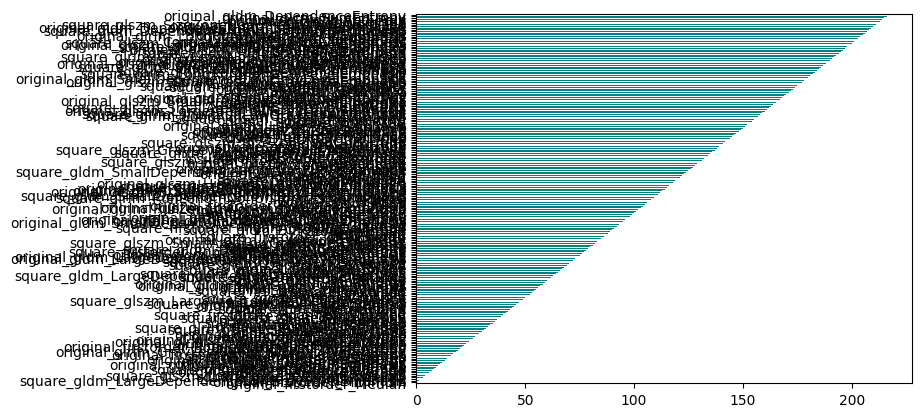

In [63]:
#Applying fisher's score for feature selection
# pip install skfeature-chappers
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x_m1df),np.array(y_m1))
feat_importance = pd.Series(ranks, x_m1df.columns[0:len(x_m1df.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
# cols = ranks[ranks<25]

In [64]:
cols = ranks[ranks<150]
print(cols)
col = x_m1df.iloc[:,cols]
col = col.columns
col = list(col)
# col.append("Diagnosis")
print(col)
x_m1df = x_m1df.loc[:,col]
print(x_m1df.shape)

[ 28  16  15  27  14   6  17  24   0   1  68  22 105  18   9 113 118 104
  26  20 130 127  58  96  74  75  76  95  59  19 139  11  97  25 145  98
 103 126  30  12 114 115 124  23  34 149   7  13  29  94  52 107  46  56
  85  37  57  93  10  55  73  77  62   8 134  92  99  45 120   3  78  41
 135  87 146 117 138 131  49   5 142  32  83 140 148  70  79  72  65 147
  64   2  47 125 111 112 136  67 116  33 110  36 119 100  39  44   4  51
  91 102  63 141  31  54  53 123  50  61  40  80  21  48  66  82  81  35
  69 101 121  71  86 108  60 133 132 137  43  88  89 106 129  84  42 143
 144  38  90 109 122 128]
['original_glszm_SmallAreaEmphasis', 'original_firstorder_Uniformity', 'original_firstorder_TotalEnergy', 'original_glszm_SizeZoneNonUniformityNormalized', 'original_firstorder_Skewness', 'original_firstorder_Maximum', 'original_firstorder_Variance', 'original_glszm_LargeAreaLowGrayLevelEmphasis', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_glcm_Cont

In [65]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_m1df.values
y = y_m1

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'Classifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0000 ± 0.0000
Score_time - Mean: 0.0180 ± 0.0081
Test_accuracy - Mean: 0.67 ± 0.02
Test_f1 - Mean: 0.78 ± 0.01
Test_roc_auc - Mean: 0.56 ± 0.03
Test_average_precision - Mean: 0.72 ± 0.03
Test_precision - Mean: 0.72 ± 0.03
Test_recall - Mean: 0.86 ± 0.02
AUPR: 0.75 ± 0.04


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6013 ± 0.0025
Score_time - Mean: 0.0063 ± 0.0077
Test_accuracy - Mean: 0.69 ± 0.02
Test_f1 - Mean: 0.81 ± 0.02
Test_roc_auc - Mean: 0.60 ± 0.07
Test_average_precision - Mean: 0.78 ± 0.05
Test_precision - Mean: 0.70 ± 0.03
Test_recall - Mean: 0.96 ± 0.03
AUPR: 0.78 ± 0.05
Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1532 ± 0.0015
Score_time - Mean: 0.0344 ± 0.0009
Test_accuracy - Mean: 0.71 ± 0.02
Test_f1 - Mean: 0.82 ± 0.02
Test_roc_auc - Mean: 0.71 ± 0.03
Test_average_precision - Mean: 0.85 ± 0.03
Test_precision - Mean: 0.74 ± 0.04
Test_recall - Mean: 0.91 ± 0.05
AUPR: 0.85 ± 0.03
Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.0843 ± 0.0058
Score_time - Mean: 0.0077 ± 0.0070
Test_accuracy - Mean: 0.71 ± 0.03
Test_f1 - Mean: 0.81 ± 0.02
Test_roc_auc - Mean: 0.73 ± 0.02
Test_average_precision - Mean: 0.86 ± 0.02
Test_precision - Mean: 0.75 ± 0.03
Test_recall - Mean: 0.88 ± 0.

In [66]:
cols = ranks[ranks<100]
print(cols)
col = x_m1df.iloc[:,cols]
col = col.columns
col = list(col)
# col.append("Diagnosis")
print(col)
x_m1df = x_m1df.loc[:,col]
print(x_m1df.shape)

[28 16 15 27 14  6 17 24  0  1 68 22 18  9 26 20 58 96 74 75 76 95 59 19
 11 97 25 98 30 12 23 34  7 13 29 94 52 46 56 85 37 57 93 10 55 73 77 62
  8 92 99 45  3 78 41 87 49  5 32 83 70 79 72 65 64  2 47 67 33 36 39 44
  4 51 91 63 31 54 53 50 61 40 80 21 48 66 82 81 35 69 71 86 60 43 88 89
 84 42 38 90]
['original_glrlm_RunPercentage', 'square_glszm_LowGrayLevelZoneEmphasis', 'square_glszm_GrayLevelVariance', 'square_firstorder_Energy', 'original_firstorder_Median', 'original_firstorder_Variance', 'square_firstorder_Range', 'original_glcm_Idm', 'original_glszm_SmallAreaEmphasis', 'original_firstorder_Uniformity', 'square_glszm_SizeZoneNonUniformityNormalized', 'original_glrlm_RunLengthNonUniformityNormalized', 'original_glszm_SizeZoneNonUniformity', 'original_firstorder_90Percentile', 'original_glcm_Idn', 'square_gldm_DependenceVariance', 'original_firstorder_Minimum', 'square_gldm_LargeDependenceLowGrayLevelEmphasis', 'square_glrlm_LongRunHighGrayLevelEmphasis', 'square_glszm_LargeAr

In [67]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_m1df.values
y = y_m1

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'Classifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0002 ± 0.0004
Score_time - Mean: 0.0150 ± 0.0015
Test_accuracy - Mean: 0.66 ± 0.02
Test_f1 - Mean: 0.78 ± 0.02
Test_roc_auc - Mean: 0.55 ± 0.02
Test_average_precision - Mean: 0.72 ± 0.03
Test_precision - Mean: 0.72 ± 0.03
Test_recall - Mean: 0.86 ± 0.03
AUPR: 0.74 ± 0.03


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.5752 ± 0.0143
Score_time - Mean: 0.0031 ± 0.0063
Test_accuracy - Mean: 0.69 ± 0.02
Test_f1 - Mean: 0.82 ± 0.02
Test_roc_auc - Mean: 0.58 ± 0.06
Test_average_precision - Mean: 0.78 ± 0.04
Test_precision - Mean: 0.70 ± 0.02
Test_recall - Mean: 0.98 ± 0.02
AUPR: 0.77 ± 0.04
Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1417 ± 0.0049
Score_time - Mean: 0.0363 ± 0.0019
Test_accuracy - Mean: 0.70 ± 0.04
Test_f1 - Mean: 0.80 ± 0.02
Test_roc_auc - Mean: 0.71 ± 0.03
Test_average_precision - Mean: 0.85 ± 0.01
Test_precision - Mean: 0.73 ± 0.03
Test_recall - Mean: 0.90 ± 0.05
AUPR: 0.85 ± 0.01
Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.0726 ± 0.0058
Score_time - Mean: 0.0017 ± 0.0034
Test_accuracy - Mean: 0.70 ± 0.02
Test_f1 - Mean: 0.80 ± 0.01
Test_roc_auc - Mean: 0.71 ± 0.03
Test_average_precision - Mean: 0.85 ± 0.02
Test_precision - Mean: 0.75 ± 0.03
Test_recall - Mean: 0.87 ± 0.

In [68]:
x_m1df = merged1.loc[:,merged1.columns!='Diagnosis']
x_m1df.shape

(808, 218)

In [69]:
# Applying variance threshold
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x_m1df)
x2.shape


mask = v_threshold.get_support(indices=True)
selected_cols = x_m1df.loc[:,x_m1df.columns[mask]]
selected_cols.columns

Index(['original_firstorder_10Percentile', 'original_firstorder_90Percentile',
       'original_firstorder_Energy', 'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median', 'original_firstorder_Minimum',
       ...
       'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count', 'Hemoglobin',
       'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP'],
      dtype='object', length=135)

In [70]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x2
y = y_m1

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")





Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0002 ± 0.0004
Score_time - Mean: 0.0165 ± 0.0053
Test_accuracy - Mean: 0.67 ± 0.02
Test_f1 - Mean: 0.78 ± 0.01
Test_roc_auc - Mean: 0.56 ± 0.03
Test_average_precision - Mean: 0.72 ± 0.03
Test_precision - Mean: 0.72 ± 0.03
Test_recall - Mean: 0.86 ± 0.02
AUPR: 0.75 ± 0.04


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod





Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.5913 ± 0.0079
Score_time - Mean: 0.0063 ± 0.0077
Test_accuracy - Mean: 0.70 ± 0.03
Test_f1 - Mean: 0.82 ± 0.02
Test_roc_auc - Mean: 0.58 ± 0.06
Test_average_precision - Mean: 0.77 ± 0.04
Test_precision - Mean: 0.70 ± 0.02
Test_recall - Mean: 0.97 ± 0.02
AUPR: 0.77 ± 0.04




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1406 ± 0.0026
Score_time - Mean: 0.0355 ± 0.0016
Test_accuracy - Mean: 0.86 ± 0.03
Test_f1 - Mean: 0.90 ± 0.02
Test_roc_auc - Mean: 0.90 ± 0.02
Test_average_precision - Mean: 0.95 ± 0.01
Test_precision - Mean: 0.85 ± 0.03
Test_recall - Mean: 0.97 ± 0.02
AUPR: 0.95 ± 0.01




Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.0895 ± 0.0077
Score_time - Mean: 0.0031 ± 0.0063
Test_accuracy - Mean: 0.89 ± 0.03
Test_f1 - Mean: 0.93 ± 0.02
Test_roc_auc - Mean: 0.94 ± 0.02
Test_average_precision - Mean: 0.96 ± 0.01
Test_precision - Mean: 0.89 ± 0.03
Test_recall - Mea

In [71]:
# Applying variance threshold
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x_m1df)
x2.shape


mask = v_threshold.get_support(indices=True)
selected_cols = x_m1df.loc[:,x_m1df.columns[mask]]
selected_cols.columns

Index(['original_firstorder_10Percentile', 'original_firstorder_90Percentile',
       'original_firstorder_Energy', 'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median', 'original_firstorder_Minimum',
       ...
       'Paedriatic_Appendicitis_Score', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Hemoglobin', 'RDW', 'Thrombocyte_Count',
       'Ketones_in_Urine', 'RBC_in_Urine', 'CRP'],
      dtype='object', length=119)

In [72]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x2
y = y_m1

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")





Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0002 ± 0.0004
Score_time - Mean: 0.0150 ± 0.0015
Test_accuracy - Mean: 0.67 ± 0.02
Test_f1 - Mean: 0.78 ± 0.01
Test_roc_auc - Mean: 0.56 ± 0.03
Test_average_precision - Mean: 0.72 ± 0.03
Test_precision - Mean: 0.72 ± 0.03
Test_recall - Mean: 0.86 ± 0.02
AUPR: 0.75 ± 0.04


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod





Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.5783 ± 0.0052
Score_time - Mean: 0.0063 ± 0.0077
Test_accuracy - Mean: 0.70 ± 0.03
Test_f1 - Mean: 0.82 ± 0.02
Test_roc_auc - Mean: 0.61 ± 0.08
Test_average_precision - Mean: 0.79 ± 0.06
Test_precision - Mean: 0.71 ± 0.03
Test_recall - Mean: 0.97 ± 0.02
AUPR: 0.78 ± 0.06




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1528 ± 0.0170
Score_time - Mean: 0.0343 ± 0.0018
Test_accuracy - Mean: 0.86 ± 0.03
Test_f1 - Mean: 0.90 ± 0.02
Test_roc_auc - Mean: 0.89 ± 0.03
Test_average_precision - Mean: 0.94 ± 0.02
Test_precision - Mean: 0.85 ± 0.03
Test_recall - Mean: 0.97 ± 0.02
AUPR: 0.94 ± 0.02




Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.0814 ± 0.0064
Score_time - Mean: 0.0032 ± 0.0064
Test_accuracy - Mean: 0.89 ± 0.01
Test_f1 - Mean: 0.92 ± 0.01
Test_roc_auc - Mean: 0.93 ± 0.03
Test_average_precision - Mean: 0.96 ± 0.01
Test_precision - Mean: 0.88 ± 0.02
Test_recall - Mea

In [73]:
# Applying variance threshold
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.5)
x2 = v_threshold.fit_transform(x_m1df)
x2.shape


mask = v_threshold.get_support(indices=True)
selected_cols = x_m1df.loc[:,x_m1df.columns[mask]]
selected_cols.columns

Index(['original_firstorder_10Percentile', 'original_firstorder_90Percentile',
       'original_firstorder_Energy', 'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median', 'original_firstorder_Minimum',
       ...
       'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Body_Temperature',
       'WBC_Count', 'Neutrophil_Percentage', 'Hemoglobin', 'RDW',
       'Thrombocyte_Count', 'Ketones_in_Urine', 'CRP'],
      dtype='object', length=117)

In [74]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x2
y = y_m1

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")





Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0013 ± 0.0021
Score_time - Mean: 0.0209 ± 0.0085
Test_accuracy - Mean: 0.67 ± 0.02
Test_f1 - Mean: 0.78 ± 0.01
Test_roc_auc - Mean: 0.56 ± 0.03
Test_average_precision - Mean: 0.72 ± 0.03
Test_precision - Mean: 0.72 ± 0.03
Test_recall - Mean: 0.86 ± 0.02
AUPR: 0.75 ± 0.04


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod





Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.5850 ± 0.0162
Score_time - Mean: 0.0062 ± 0.0077
Test_accuracy - Mean: 0.69 ± 0.03
Test_f1 - Mean: 0.81 ± 0.02
Test_roc_auc - Mean: 0.60 ± 0.08
Test_average_precision - Mean: 0.78 ± 0.06
Test_precision - Mean: 0.70 ± 0.03
Test_recall - Mean: 0.96 ± 0.02
AUPR: 0.78 ± 0.06




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1452 ± 0.0041
Score_time - Mean: 0.0348 ± 0.0015
Test_accuracy - Mean: 0.84 ± 0.03
Test_f1 - Mean: 0.89 ± 0.02
Test_roc_auc - Mean: 0.89 ± 0.03
Test_average_precision - Mean: 0.94 ± 0.01
Test_precision - Mean: 0.84 ± 0.04
Test_recall - Mean: 0.95 ± 0.03
AUPR: 0.94 ± 0.02




Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.0794 ± 0.0021
Score_time - Mean: 0.0031 ± 0.0063
Test_accuracy - Mean: 0.88 ± 0.02
Test_f1 - Mean: 0.92 ± 0.01
Test_roc_auc - Mean: 0.93 ± 0.02
Test_average_precision - Mean: 0.96 ± 0.01
Test_precision - Mean: 0.88 ± 0.03
Test_recall - Mea

In [75]:
x_m1df = merged1.loc[:,merged1.columns!='Diagnosis']
x_m1df.shape

(808, 218)

BMI                                              0.320728
Age                                              0.319988
Neutrophil_Percentage                            0.309225
Thrombocyte_Count                                0.227109
RBC_Count                                        0.213915
                                                   ...   
original_glcm_Id                                 0.000000
square_glrlm_GrayLevelNonUniformityNormalized    0.000000
square_glcm_SumSquares                           0.000000
square_ngtdm_Busyness                            0.000000
original_firstorder_10Percentile                 0.000000
Length: 218, dtype: float64

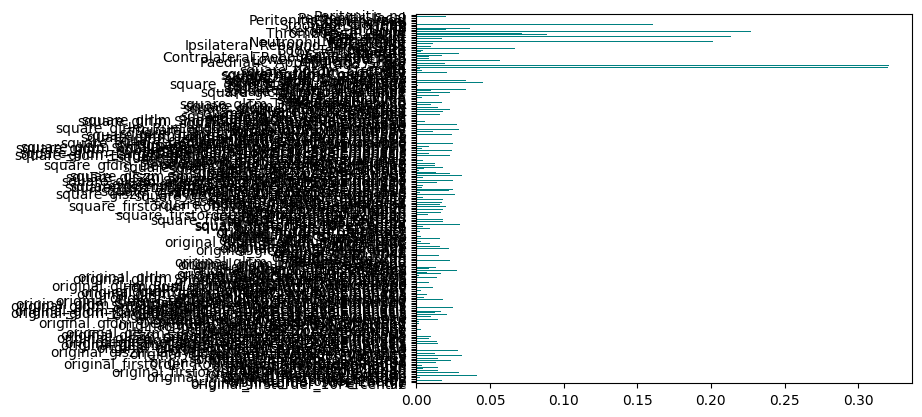

In [76]:
# Applying Information Gain for feature Selection:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x_m1df,y,random_state=0)
feat_importance = pd.Series(importance, x_m1df.columns[0:len(x_m1df.columns)])
feat_importance.plot(kind='barh',color = 'teal')


mutual_info = pd.Series(importance)
mutual_info.index = x_m1df.columns
mutual_info.sort_values(ascending=False)




In [77]:
cols = mutual_info[mutual_info>0].index
cols
x_m1_ig1 = x_m1df.loc[:,cols]
x_m1_ig1.shape

(808, 161)

In [78]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_m1_ig1.values
y = y_m1

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")





Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0000 ± 0.0000
Score_time - Mean: 0.0220 ± 0.0060
Test_accuracy - Mean: 0.67 ± 0.02
Test_f1 - Mean: 0.78 ± 0.01
Test_roc_auc - Mean: 0.56 ± 0.03
Test_average_precision - Mean: 0.72 ± 0.03
Test_precision - Mean: 0.72 ± 0.03
Test_recall - Mean: 0.86 ± 0.02
AUPR: 0.75 ± 0.04


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod





Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.5905 ± 0.0119
Score_time - Mean: 0.0038 ± 0.0076
Test_accuracy - Mean: 0.70 ± 0.01
Test_f1 - Mean: 0.82 ± 0.01
Test_roc_auc - Mean: 0.61 ± 0.05
Test_average_precision - Mean: 0.79 ± 0.04
Test_precision - Mean: 0.71 ± 0.02
Test_recall - Mean: 0.97 ± 0.03
AUPR: 0.78 ± 0.05




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1440 ± 0.0029
Score_time - Mean: 0.0338 ± 0.0004
Test_accuracy - Mean: 0.85 ± 0.04
Test_f1 - Mean: 0.90 ± 0.03
Test_roc_auc - Mean: 0.90 ± 0.03
Test_average_precision - Mean: 0.95 ± 0.01
Test_precision - Mean: 0.85 ± 0.03
Test_recall - Mean: 0.95 ± 0.03
AUPR: 0.95 ± 0.01




Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.0971 ± 0.0041
Score_time - Mean: 0.0098 ± 0.0048
Test_accuracy - Mean: 0.89 ± 0.02
Test_f1 - Mean: 0.93 ± 0.01
Test_roc_auc - Mean: 0.95 ± 0.02
Test_average_precision - Mean: 0.97 ± 0.01
Test_precision - Mean: 0.88 ± 0.02
Test_recall - Mea

In [79]:
cols = mutual_info[mutual_info>0.03].index
cols
x_m1_ig2 = x_m1df.loc[:,cols]
x_m1_ig2.shape

(808, 22)

In [80]:
print(x_m1_ig2.columns)

Index(['original_firstorder_InterquartileRange',
       'original_firstorder_Uniformity', 'original_glszm_SmallAreaEmphasis',
       'original_gldm_GrayLevelNonUniformity',
       'square_glszm_SmallAreaHighGrayLevelEmphasis',
       'square_glcm_JointAverage', 'square_glcm_MaximumProbability',
       'square_glcm_SumAverage', 'Age', 'BMI', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Body_Temperature', 'Psoas_Sign',
       'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count', 'Hemoglobin', 'RDW',
       'Thrombocyte_Count', 'RBC_in_Urine', 'CRP'],
      dtype='object')


In [81]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = ADABOOST2
X = x_m1_ig2.values
y = y_m1

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


# model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]
model_list =[ADABOOST2]
for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")





Classifier: AdaBoostClassifier(algorithm='SAMME', estimator=LGBMClassifier(verbose=-1),
                   learning_rate=0.01, n_estimators=200, random_state=42)
Fit_time - Mean: 0.0321 ± 0.0016
Score_time - Mean: 0.0041 ± 0.0046
Test_accuracy - Mean: 0.91 ± 0.03
Test_f1 - Mean: 0.94 ± 0.02
Test_roc_auc - Mean: 0.87 ± 0.03
Test_average_precision - Mean: 0.90 ± 0.03
Test_precision - Mean: 0.90 ± 0.03
Test_recall - Mean: 0.97 ± 0.02
AUPR: 0.95 ± 0.02


In [82]:
pip install boruta

Note: you may need to restart the kernel to use updated packages.


In [83]:
# #Applying Boruta Algorithm for feature Selection
# #Applying BORUTA algorithm

# # from sklearn.datasets import load_diabetes
# from sklearn.ensemble import RandomForestRegressor
# from boruta import BorutaPy
# import pandas as pd
# import numpy as np

# # # let's load the load_diabetes() dataset from sklearn
# # X, y = load_diabetes(return_X_y=True, as_frame=True)

# # let's initialize a RF model
# model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
# model.fit(x_m1df,y_m1)

# # let's initialize Boruta
# feat_selector = BorutaPy(
#     verbose=2,
#     estimator=model,
#     n_estimators='auto',
#     max_iter=10  # number of iterations to perform

# )

# # train Boruta
# # N.B.: X and y must be numpy arrays

# feat_selector.fit(X_m1,y_m1)

# # print support and ranking for each feature
# print("\n------Support and Ranking for each feature------")
# for i in range(len(feat_selector.support_)):
#     if feat_selector.support_[i]:
#         print("Passes the test: ", x_m1df.columns[i],
#               " - Ranking: ", feat_selector.ranking_[i])
#     else:
#         print("Doesn't pass the test: ",
#               x_m1df.columns[i], " - Ranking: ", feat_selector.ranking_[i])



# sel_col = pd.Series(feat_selector.ranking_,index=x_m1df.columns)
# sel_col.sort_values(inplace=True)



# sel_col.plot(kind='bar',yticks=np.arange(218)) #It gives rank so aork accordingly



# # brt15 = sel_col[sel_col.values<16]
# # brt15.index

In [84]:
print(type(y_m1),type(x_m1df.values))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [85]:
# brt15 = sel_col[sel_col.values<16]
# brt15.index

In [86]:
!pip install shap

     ---------------------------------------- 0.0/57.6 kB ? eta -:--:--
     ----------------------------------- ---- 51.2/57.6 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 57.6/57.6 kB 1.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/453.3 kB ? eta -:--:--
   ---------------------------- ----------- 327.7/453.3 kB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 453.3/453.3 kB 5.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/78.3 kB ? eta -:--:--
   ---------------------------------------- 78.3/78.3 kB 4.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------ --------------------------------- 0.4/2.7 MB 12.9 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.7 MB 10.2 MB/s eta 0:00:01
   ------------------ --------------------- 1.2/2.7 MB 9.8 MB/s eta 0:00:01
   ---------------------- ----------------- 1.5/2.7 MB 8.8 MB/s eta 0:00:01
   -----------

In [87]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X_m1,y_m1,random_state=42,test_size= 0.2)

In [88]:
#Applying Shap Value
# !pip install shap
import shap
model = LGBM
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)

PermutationExplainer explainer: 163it [00:24,  4.91it/s]                                                               


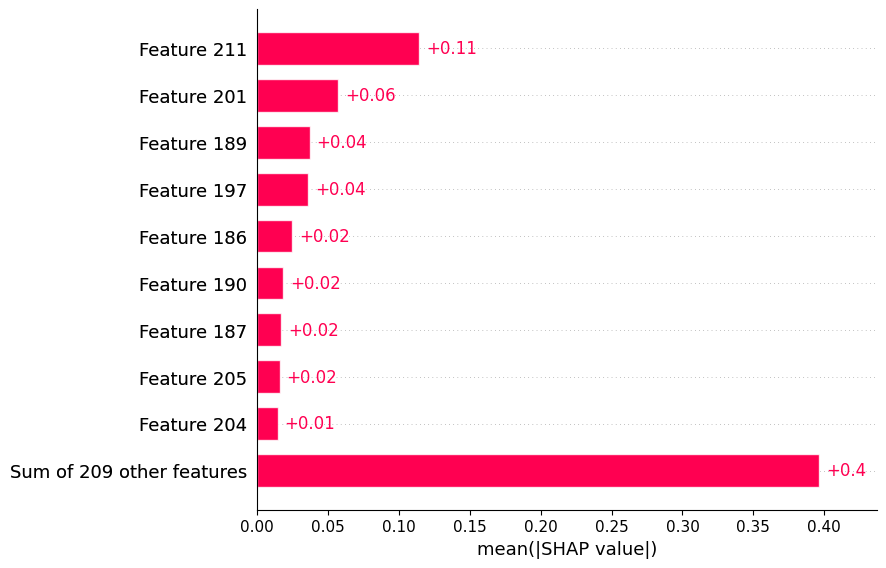

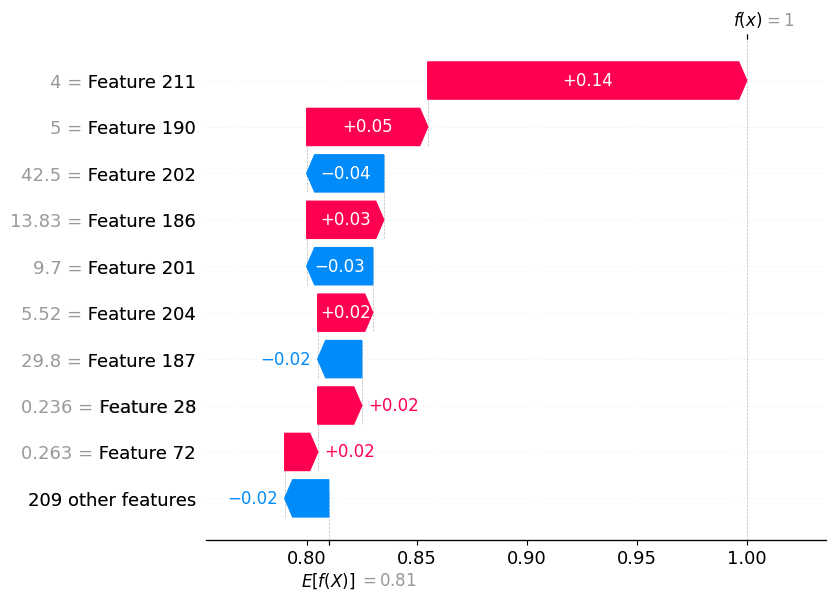

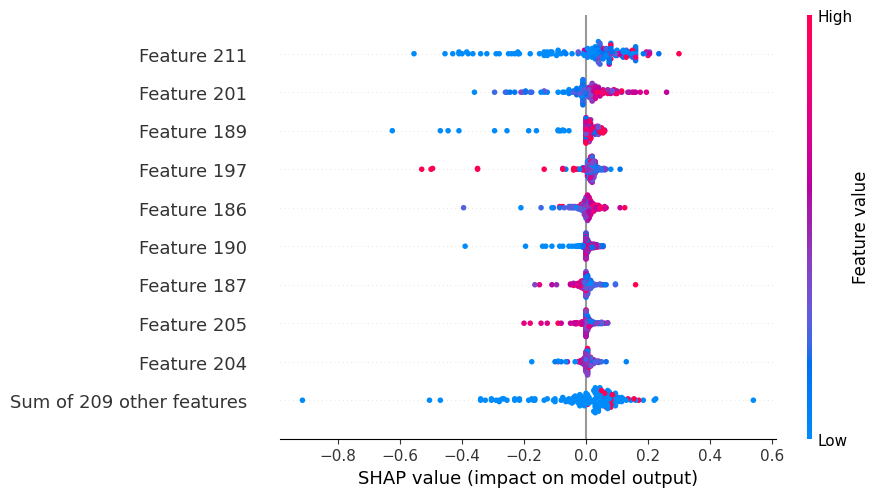

In [89]:
shap.plots.bar(shap_values,)
shap.plots.waterfall(shap_values[0])
shap.plots.beeswarm(shap_values)

In [90]:
values = shap_values[shap_values[0]!=0]

In [91]:
# import numpy as np

# Assuming shap_values is already computed using your code
# shap_values = explainer(x_test)

# Get the mean absolute SHAP values for each feature
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# Filter columns with SHAP values greater than 0
selected_columns = x_m1df.columns[mean_abs_shap > 0]

# Select only those columns from x_test
x_m1df_shap = x_m1df.loc[:,selected_columns]
print(selected_columns)
x_m1df_shap.shape

Index(['original_firstorder_10Percentile', 'original_firstorder_90Percentile',
       'original_firstorder_Energy', 'original_firstorder_Entropy',
       'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median',
       ...
       'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP', 'Stool_constipation', 'Stool_normal',
       'Peritonitis_local', 'Peritonitis_no'],
      dtype='object', length=194)


(808, 194)

In [92]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_m1df_shap.values
y = y_m1

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")





Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0033 ± 0.0062
Score_time - Mean: 0.0138 ± 0.0039
Test_accuracy - Mean: 0.67 ± 0.02
Test_f1 - Mean: 0.78 ± 0.01
Test_roc_auc - Mean: 0.56 ± 0.03
Test_average_precision - Mean: 0.72 ± 0.03
Test_precision - Mean: 0.72 ± 0.03
Test_recall - Mean: 0.86 ± 0.02
AUPR: 0.75 ± 0.04


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod





Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.5913 ± 0.0063
Score_time - Mean: 0.0000 ± 0.0000
Test_accuracy - Mean: 0.69 ± 0.02
Test_f1 - Mean: 0.82 ± 0.01
Test_roc_auc - Mean: 0.60 ± 0.06
Test_average_precision - Mean: 0.79 ± 0.05
Test_precision - Mean: 0.70 ± 0.03
Test_recall - Mean: 0.97 ± 0.02
AUPR: 0.78 ± 0.05




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1425 ± 0.0024
Score_time - Mean: 0.0352 ± 0.0013
Test_accuracy - Mean: 0.86 ± 0.03
Test_f1 - Mean: 0.91 ± 0.02
Test_roc_auc - Mean: 0.90 ± 0.02
Test_average_precision - Mean: 0.94 ± 0.01
Test_precision - Mean: 0.85 ± 0.03
Test_recall - Mean: 0.98 ± 0.02
AUPR: 0.94 ± 0.01




Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.1187 ± 0.0082
Score_time - Mean: 0.0099 ± 0.0081
Test_accuracy - Mean: 0.89 ± 0.03
Test_f1 - Mean: 0.93 ± 0.02
Test_roc_auc - Mean: 0.94 ± 0.02
Test_average_precision - Mean: 0.96 ± 0.01
Test_precision - Mean: 0.89 ± 0.04
Test_recall - Mea

**APPLYIG INFO GAIN ON COMPLETE DATA**

In [93]:
data = pd.read_csv('/content/drive/MyDrive/Research/Data/new_merged_complete.csv')
data
data = data.drop(['US_Number'],axis=1)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Research/Data/new_merged_complete.csv'

In [ ]:
x = data.loc[:,data.columns!="Diagnosis"]
y = data.loc[:,"Diagnosis"]

In [ ]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x.values
y = y.values

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')


mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)


cols = mutual_info[mutual_info>0].index
cols

In [ ]:
x_ig1 = x.loc[:,cols]
x_ig1.shape

In [ ]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_ig1.values
y = y

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')


mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)


cols = mutual_info[mutual_info>0.01].index
cols

In [ ]:
x_ig2 = x.loc[:,cols]
x_ig2.shape

In [ ]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_ig2.values
y = y

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

In [ ]:
cols = mutual_info[mutual_info>0.03].index
cols
x_ig3 = x.loc[:,cols]
x_ig3.shape

In [ ]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_ig3.values
y = y

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

In [ ]:
cols = mutual_info[mutual_info>0.05].index
cols
x_ig4 = x.loc[:,cols]
x_ig4.shape

In [ ]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_ig4.values
y = y

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

In [ ]:
x_ig2.columns

In [ ]:
print(x_ig4.columns)

##TAKING LOG AND WAVELET ONLY

In [ ]:
original = [col for col in data.columns if col.startswith('original')]
squared = [col for col in data.columns if col.startswith('square')]
data = data.drop(columns=original+squared)

In [ ]:
data

In [ ]:
x = data.loc[:,data.columns!="Diagnosis"]
y = data.loc[:,"Diagnosis"]

In [ ]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x.values
y = y.values

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


# model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]
model_list = [KNN,LGBM]
for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')


mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)


cols = mutual_info[mutual_info>0].index
cols

In [ ]:
x_lw_ig1 = x.loc[:,cols]

In [ ]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_lw_ig1.values
y = y

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


# model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]
model_list = [KNN,LGBM]
for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

##Applying info gain on image only

In [ ]:
# df = pd.read_csv("/content/drive/MyDrive/Research/Data/image_complete.csv")

df = pd.read_csv("C:\\Users\\A\\Desktop\\Research_Project\\Data\\image_complete.csv")
df

In [ ]:
df = df.drop(columns=['Unnamed: 0','US_Number','ImageName'])
df

In [ ]:
df = df.drop_duplicates()
df

In [ ]:
df["Diagnosis"].value_counts()

In [ ]:
x = df.loc[:,df.columns!='Diagnosis']
y = df.loc[:,df.columns=='Diagnosis']

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')


mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)




In [ ]:
cols = mutual_info[mutual_info>0].index
cols
x_ig1 = x.loc[:,cols]
x_ig1.shape

In [ ]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_ig1.values
y = y

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]
# model_list = [KNN,LGBM]
for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

In [ ]:
cols = mutual_info[mutual_info>0.01].index
cols
x_ig2 = x.loc[:,cols]
x_ig2.shape

In [ ]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = RF
X = x_ig2.values
y = y

def calculate_all(model, X, y, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG, RF, LGBM, XGB, ADABOOST]
# model_list = [KNN,LGBM]
for model in model_list:
    # invoking function

    results = calculate_all(model, X, y)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

In [ ]:
# # import numpy as np
# # import tensorflow as tf
# # from tensorflow.keras.models import Sequential
# # from tensorflow.keras.layers import LSTM, Dense, Embedding, Bidirectional
# # from tensorflow.keras.preprocessing.sequence import pad_sequences
# # from sklearn.model_selection import train_test_split

# # # Assuming you have your data loaded and preprocessed
# # X_train, X_test, y_train, y_test = train_test_split(X,y,random_state =42)

# # # Padding sequences if necessary
# # max_sequence_length = 100
# # X_train = pad_sequences(X_train, maxlen=max_sequence_length)
# # X_test = pad_sequences(X_test, maxlen=max_sequence_length)

# # # Define the LSTM model
# # model = Sequential()
# # model.add(Embedding(input_dim=1000, output_dim=100, input_length=100))
# # model.add(Bidirectional(LSTM(units=64, return_sequences=True)))
# # model.add(Bidirectional(LSTM(units=32)))
# # model.add(Dense(units=1, activation='sigmoid'))

# # # Compile the model
# # model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # # Train the model
# # batch_size = 32
# # epochs = 10
# # model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))

# # # Evaluate the model
# # loss, accuracy = model.evaluate(X_test, y_test)
# # print(f'Test accuracy: {accuracy}')


# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Embedding, Bidirectional
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

# # Assuming you have your data loaded and preprocessed
# X, y = x,y

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Padding sequences if necessary
# max_sequence_length = X_train.shape[1]  # Use the number of columns as the sequence length
# X_train = pad_sequences(X_train, maxlen=max_sequence_length)
# X_test = pad_sequences(X_test, maxlen=max_sequence_length)

# # Define the LSTM model
# model = Sequential()
# model.add(Embedding(input_dim=X_train.shape[1], output_dim=100, input_length=max_sequence_length))
# model.add(Bidirectional(LSTM(units=64, return_sequences=True)))
# model.add(Bidirectional(LSTM(units=32)))
# model.add(Dense(units=1, activation='sigmoid'))

# # Compile the model
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Train the model
# model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# # Evaluate the model
# y_pred = model.predict_classes(X_test)
# accuracy = accuracy_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)
# auroc = roc_auc_score(y_test, y_pred)
# aupr = average_precision_score(y_test, y_pred)

# # Print evaluation metrics
# print(f'Accuracy: {accuracy:.4f}')
# print(f'F1 Score: {f1:.4f}')
# print(f'AUROC: {auroc:.4f}')
# print(f'AUPR: {aupr:.4f}')


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

# Assuming you have your data loaded and preprocessed
X, y = x,y

# Define model parameters
vocab_size = 10000
embedding_dim = 100
max_sequence_length = 200

# Initialize metrics lists
accuracy_scores = []
f1_scores = []
auroc_scores = []
aupr_scores = []

# Perform 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Padding sequences
    X_train = pad_sequences(X_train, maxlen=max_sequence_length)
    X_test = pad_sequences(X_test, maxlen=max_sequence_length)

    # Define the LSTM model
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    model.add(Bidirectional(LSTM(units=64, return_sequences=True)))
    model.add(Bidirectional(LSTM(units=32)))
    model.add(Dense(units=1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

    # Evaluate the model
    y_pred = model.predict_classes(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auroc = roc_auc_score(y_test, y_pred)
    aupr = average_precision_score(y_test, y_pred)

    # Append metrics to lists
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    auroc_scores.append(auroc)
    aupr_scores.append(aupr)

# Calculate mean and standard deviation of metrics
accuracy_mean = np.mean(accuracy_scores)
accuracy_std = np.std(accuracy_scores)
f1_mean = np.mean(f1_scores)
f1_std = np.std(f1_scores)
auroc_mean = np.mean(auroc_scores)
auroc_std = np.std(auroc_scores)
aupr_mean = np.mean(aupr_scores)
aupr_std = np.std(aupr_scores)

# Print results
print(f'Accuracy: {accuracy_mean:.4f} +- {accuracy_std:.4f}')
print(f'F1 Score: {f1_mean:.4f} +- {f1_std:.4f}')
print(f'AUROC: {auroc_mean:.4f} +- {auroc_std:.4f}')
print(f'AUPR: {aupr_mean:.4f} +- {aupr_std:.4f}')
